# Exercise 1: Linear regression
Initially we will work on 2D points and then expand it out to 3D.

We'll do the necessary imports for the notebook and then generate some data.

The data generation is as follows:
$$
x \sim \mathcal{N}(\mu_x, \sigma_x^2)
$$ 
with $\mu_x=1.5$ being the mean and $\sigma_x = 2.5$ being the standard deviation.

We also add a normally distributed error term with zero mean $\mu_\epsilon=0$ and standard deviation
$\sigma_\epsilon=0.5$.

In [ ]:
import numpy as np
import open3d as o3d
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Generate 'random' data
np.random.seed(0)
x = np.random.normal(1.5, 2.5, 100)       # Array of 100 values with mean = 1.5, stddev = 2.5
res = np.random.normal(0, 0.5, 100)       # Generate 100 residual terms (mean=0, std=0.5)
y = 2 + 0.3 * x + res                     # Actual values of Y

### Other types of Y typical for linear regression

Simple Linear Regression
$$ y = \beta_0 + \beta_1 x + \text{residual} $$
python:
y = beta0 + beta1 * x + res
<br><br><br><br><br>

Multiple Linear Regression
$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \varepsilon $$
python:
y = beta0 + beta1*x1 + beta2*x2 + ... + betap*xp + eps
<br><br><br><br><br>

Polynomial Regression
$$ y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_k x^k + \varepsilon $$
y = beta0 + beta1*x + beta2*(x**2) + ... + betak*(x**k) + eps

<br><br><br><br><br>
Log-Linear Model
$$ \log(y) = \beta_0 + \beta_1 x + \varepsilon $$
python:
log_y = beta0 + beta1*x + eps
<br><br><br><br><br>

Interaction Model
$$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 (x_1 x_2) + \varepsilon $$
python: 
y = beta0 + beta1*x1 + beta2*x2 + beta3*(x1*x2) + eps

<br><br><br><br><br>
$$ y = \beta_0 + \beta_1 (x - \bar{x}) + \varepsilon $$
pyton:
y = beta0 + beta1*(x - x.mean()) + eps


We can use the linear regression algorithm from the `sklearn` package.
Here, we setup the model to fit `x` to `y`.

In [ ]:
x_r = x.reshape(-1,1) #fit needs x in this shape (n_samples, 1)
# Initialise and fit model
lm = LinearRegression()
model = lm.fit(x_r, y)

We can now predict new outcomes given new data.

In [4]:
# Draw a new datapoint
tst_x = 2.5 * np.random.randn(1).reshape(-1,1) + 1.5   
print(tst_x)
resulting_y = model.predict(tst_x)
print(resulting_y)

[[0.57704541]]
[2.18951787]


Drawing 200 new samples and plotting them as a line shows us that we have gotten a decent fit.

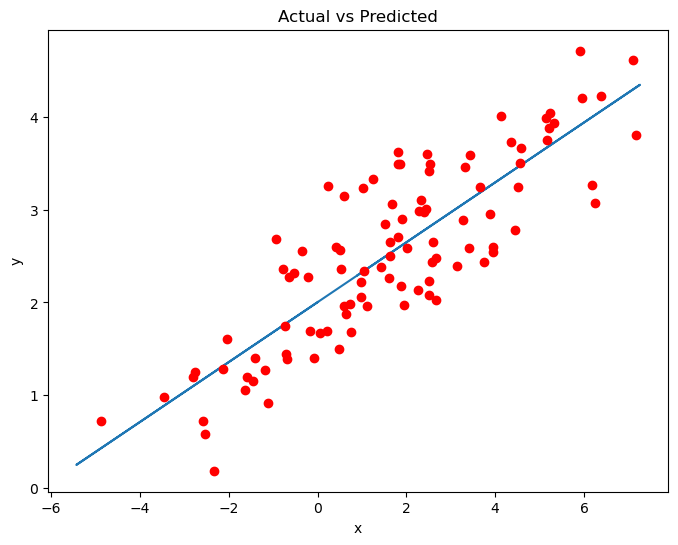

In [5]:
new_x = 2.5 * np.random.randn(200).reshape(-1,1) + 1.5   
predicted = model.predict(new_x)
plt.figure(figsize=(8, 6))
plt.plot(new_x, predicted)     # regression line
plt.plot(x, y, 'ro')   # scatter plot showing actual data
plt.title('Actual vs Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Exercises
### A
Using [Ordinary Least Squares (OLS)](https://en.wikipedia.org/wiki/Ordinary_least_squares), attempt to get a regression line that is equal to the one `sklearn` provides.

Assuming that the data is modeled by the following, having $N$ data points available:
$$
\underbrace{\hat{\mathbf{y}}}_{N \times 1} = \underbrace{\mathbf{X}}_{N\times (K+1)} \underbrace{\beta^\text{*}}_{(K+1) \times 1} + \underbrace{\varepsilon}_{N \times 1} 
$$
Ordinary Least squares optimizes the parameters $\beta$ such that the resdiual error (measured by the Sum of Squared Errors (SSE) objective/loss function $L$) is minimal (regression). That is:
$$
L(\mathbf{X}_i, y_i;\mathbf{\beta}) = \sum_{i=1}^N (y_i - \hat{y_i})^2 \\
\beta^\text{*} = \argmin_\beta L(\mathbf{X}, \mathbf{y};\beta)
$$
where $y_i$ is the true value and $\hat{y_i}$ is the predicted value given a point $\mathbf{X}_i \in \mathbb{R}$.
We won't go into detail here how to solve this optimization problem but instead give you the solution directly:
$$
\beta^\text{*} = (\mathbf{X}^\top \mathbf{X})^{-1}\mathbf{X}^\top \mathbf{y}
$$
Using this, you need to organize your data in matrices of shapes $(N, K+1)$ for $\mathbf{X}$ with $N$ being the number of data points and $K$ being the dimension of $\mathbf{X_i}$, i.e. $\mathbf{X}_i \in \mathbb{R}^K$. The $+1$ is for the intercept, so $\beta_0$ will be our intercept term. For $\mathbf{y}$, you need to make sure it is of shape $(N, 1)$. So, the first row of $\mathbf{X}$ would look like this if $\mathbf{X}_i \in \mathbb{R}$:
$$
\mathbf{X_0} = \begin{bmatrix}1 & x_{1,0}\end{bmatrix}
$$
<details open>
<summary>If the above formulation is too complicated, here's another formulation</summary>
<br>
Assuming
Yₑ = α + β X

![ols.gif](ols.gif "ols")

- β = Cov(X, Y) / Var(X).
- α = mean(Y)-β*mean(X)

</br>
</details>

### B
Extend what we have shown above to 3D predict a plane using Linear regression given a point cloud.

Planes can be plotted with 
```{Python}
x = np.linspace(start, end, n)
y = np.linspace(start, end, n)
xx, yy = np.meshgrid(x_t, y_t)

ax.plot_surface(xx, yy, predicted_zz, alpha=0.2)
```

# Task A

sklearn intercept: 2.0031670124623435
sklearn slope    : 0.3229396867092759
manual intercept: 2.003167012462343
manual slope    : 0.32293968670927636


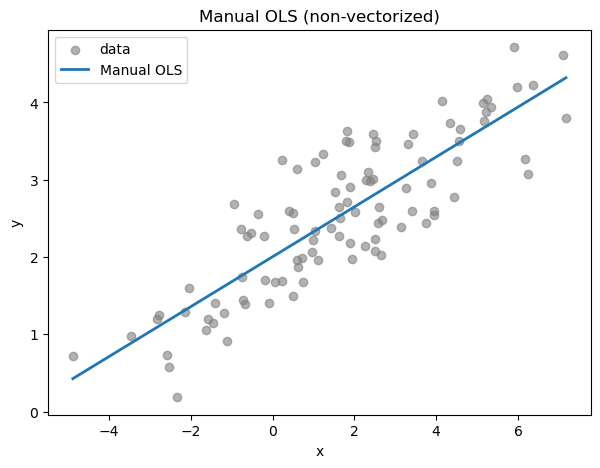

In [30]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate synthetic data
# -----------------------------
np.random.seed(0)
x = np.random.normal(1.5, 2.5, 100)       # shape (100,)
res = np.random.normal(0, 0.5, 100)
y = 2 + 0.3 * x + res                     # shape (100,)

# -----------------------------
# 2. sklearn reference solution
# -----------------------------
X = x.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)

sk_intercept = float(model.intercept_)
sk_slope     = float(model.coef_[0])

print("sklearn intercept:", sk_intercept)
print("sklearn slope    :", sk_slope)

# -----------------------------
# 3. Manual OLS (no matrices)
# -----------------------------
n = len(x)

# Means
x_mean = sum(x) / n
y_mean = sum(y) / n

# Compute numerator and denominator for slope
num = 0.0   # Σ (x_i - x̄)(y_i - ȳ)
den = 0.0   # Σ (x_i - x̄)^2

for i in range(n):
    dx = x[i] - x_mean
    dy = y[i] - y_mean
    num += dx * dy
    den += dx * dx

slope_manual = num / den
intercept_manual = y_mean - slope_manual * x_mean

print("manual intercept:", intercept_manual)
print("manual slope    :", slope_manual)

# -----------------------------
# 4. Predicted line using manual OLS
# -----------------------------
y_pred_manual = [intercept_manual + slope_manual * xi for xi in x]

# -----------------------------
# 5. Plot
# -----------------------------
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="gray", alpha=0.6, label="data")

# Sort x for a nice line
x_sorted_idx = np.argsort(x)
x_sorted = x[x_sorted_idx]
y_pred_sorted = np.array(y_pred_manual)[x_sorted_idx]

plt.plot(x_sorted, y_pred_sorted, label="Manual OLS", linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Manual OLS (non-vectorized)")
plt.show()


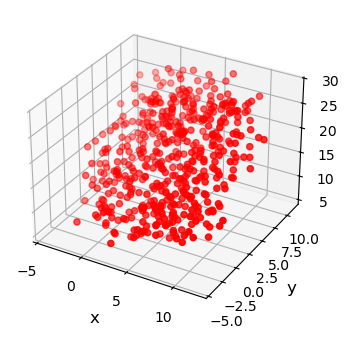

In [6]:
# Creating a pointcloud.
pc = o3d.io.read_point_cloud("TestData/spread_points.ply")
xyz = np.asarray(pc.points)

fig = plt.figure(figsize=(6,4))
ax = plt.axes(projection='3d')
ax.scatter3D(xyz[:,0], xyz[:,1], xyz[:,2], color = 'red')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
plt.show()


In [32]:
## We want to predict Z
xy = xyz[:,:2] # our inputs
z = xyz[:,2].reshape(-1,1) # our targets

Plane coefficients:
b0 = 10.813637419101857
b1 = 0.0324493693596246
b2 = 1.526955219522534


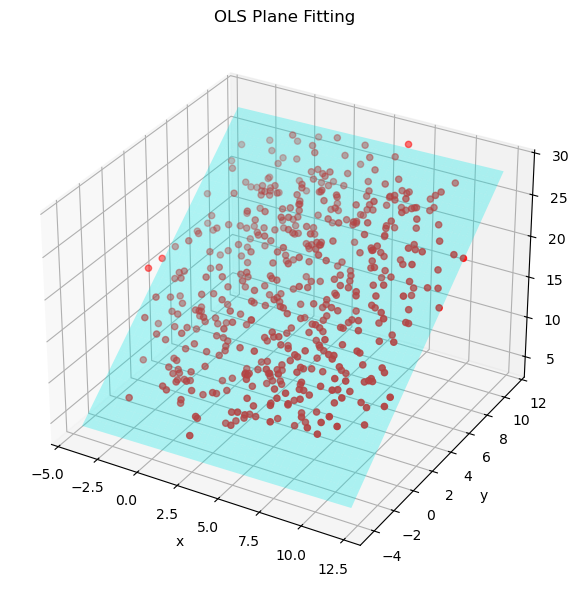

In [34]:
# -------------------------------------
# 1. Load point cloud
# -------------------------------------
pc = o3d.io.read_point_cloud("TestData/spread_points.ply")
xyz = np.asarray(pc.points)

x = xyz[:,0]
y = xyz[:,1]
z = xyz[:,2]

# -------------------------------------
# 2. Build design matrix for plane fit
#    z = b0 + b1*x + b2*y
# -------------------------------------
X = np.column_stack([np.ones(len(x)), x, y])   # shape (N, 3)

# OLS: β = (Xᵀ X)^(-1) Xᵀ z
beta = np.linalg.inv(X.T @ X) @ (X.T @ z)

b0, b1, b2 = beta
print("Plane coefficients:")
print("b0 =", b0)
print("b1 =", b1)
print("b2 =", b2)

# -------------------------------------
# 3. Create meshgrid for plotting plane
# -------------------------------------
x_range = np.linspace(x.min(), x.max(), 40)
y_range = np.linspace(y.min(), y.max(), 40)
xx, yy = np.meshgrid(x_range, y_range)

zz = b0 + b1 * xx + b2 * yy   # predicted plane

# -------------------------------------
# 4. Visualize with rotation enabled
# -------------------------------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(x, y, z, color='red', label='Point Cloud')

ax.plot_surface(xx, yy, zz, alpha=0.3, color='cyan', edgecolor='none')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("OLS Plane Fitting")

# Enable rotation
plt.tight_layout()
plt.show()
